In [82]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
from scipy.optimize import curve_fit
import scipy.signal
from scipy.io import loadmat
import json
import re
from scipy.interpolate import interp1d
import scipy.signal as signal
from sklearn.metrics import r2_score
from scipy.stats import linregress


# Ensure plots are rendered in the notebook
%matplotlib inline

## Curve fitting one motor speed to extract magnitude and timescales of speed change

In [83]:
# Define exponential functions
def exp_decrease(t, A, tau, C, t0):
    return A / (1 + np.exp((t-175-t0) / tau)) + C

def exp_increase(t, B, tau, D):
    return B * (1 - np.exp(-(t - 270) / tau)) + D

def calculate_time_constants(time, speed, filename):
    results = []

    #normalize speed for ease of fitting
    speed = speed / np.average(speed[time<=180]) #normally 300

    # Filter data for decrease and increase
    mask_decrease = (time >= 175) & (time <= 240)
    time_decrease = time[mask_decrease]
    speed_decrease = speed[mask_decrease]

    mask_increase = (time > 270) & (time <= 360)
    time_increase = time[mask_increase]
    speed_increase = speed[mask_increase]

    # Fit the decrease segment
    try:
        popt_decrease, _ = curve_fit(
            exp_decrease,
            time_decrease,
            speed_decrease,
            p0=[1-np.min(speed_decrease), 10, np.min(speed_decrease), 10],
        )
        A_dec, tau_dec, C_dec, t0_dec = popt_decrease
    except Exception as e:
        print(f"Error fitting decrease for {filename}: {e}")
        tau_dec = np.nan
        A_dec, tau_dec, C_dec, t0_dec = [np.nan, np.nan, np.nan, np.nan]
        popt_decrease = [np.nan, np.nan, np.nan, np.nan]

    # if True: #plotting to double check
    #     if filename == "500": #filename[-13:-10]
    #         plt.plot(time, speed)
    #         plt.plot(time_decrease, exp_decrease(time_decrease, *popt_decrease))

    # Fit the increase segment
    try:
        popt_increase, _ = curve_fit(
            exp_increase, time_increase, speed_increase, p0=[1, 50, 0.5]
        )
        B_inc, tau_inc, D_inc = popt_increase
    except Exception as e:
        print(f"Error fitting increase for {filename}: {e}")
        tau_inc = np.nan
        popt_increase = [np.nan, np.nan, np.nan]

    # Save results for this concentration
    condition = filename.split(".csv")[
        0
    ]  # Assuming the filename contains the concentration info
    results.append(
        {
            "Condition": condition,
            "Tau (Decrease)": tau_dec,
            "Tau (Increase)": tau_inc,
            "Time Range (Decrease)": f"180-270",
            "Time Range (Increase)": f"270-{time[-1]}",
        }
    )

    return tau_dec, t0_dec, A_dec, tau_inc

In [84]:
def convert_to_300fps(time_stamps, data, target_fps=300):# Calculate the total duration
    total_time = time_stamps[-1]
    
    # Generate new time stamps at the target FPS
    new_time_stamps = np.linspace(0, total_time, int(total_time * target_fps))
    
    # Create a linear interpolator
    interpolator = interp1d(time_stamps, data, kind='linear', fill_value='extrapolate')
    
    # Interpolate data to the new time stamps
    interpolated_data = interpolator(new_time_stamps)
    
    return new_time_stamps[:380*target_fps], interpolated_data[:380*target_fps]

def bin_data(time_stamps, data, bin_size=0.1):
    data = data[time_stamps < 380]
    time_stamps = time_stamps[time_stamps < 380]
    
    # Determine the range of time stamps
    start_time = 0
    end_time = 380
    
    # Create bin edges
    bin_edges = np.arange(start_time, end_time + bin_size, bin_size)
    
    # Calculate bin indices for each time stamp
    bin_indices = np.digitize(time_stamps, bin_edges, right=False) - 1  # Bin indices (0-based)

    # Initialize lists to store results
    binned_times = np.arange(0,end_time,0.1)
    averaged_data = np.zeros_like(binned_times)
    
    # Iterate over each bin
    for i in range(len(bin_edges) - 1):
        # Get indices of data points in the current bin
        indices_in_bin = np.where(bin_indices == i)[0]
        
        if len(indices_in_bin) > 0:
            # Calculate the midpoint of the current bin
            bin_midpoint = (bin_edges[i] + bin_edges[i + 1]) / 2
            binned_times[i] = (bin_midpoint)
            
            # Calculate the average of data points in the current bin
            average_value = np.mean(data[indices_in_bin])
            averaged_data[i] = (average_value)
    
    return np.array(binned_times), np.array(averaged_data)

def bin_data_2(time_stamps, data, bin_size=0.1):
    T = time_stamps[time_stamps<=380]
    F = data[time_stamps<=380]
    
    # Resample into 4000 bins
    data_F = np.zeros(3800)
    data_T = np.zeros(3800)

    bin = 0
    counter = 0

    for kk in range(len(T)):
        counter += 1
        pos = int(T[kk] // 0.1)
        if pos < 3800:
            data_F[pos] += F[kk]
            if T[kk] // 0.1 > bin + 1:
                data_F[pos - 1] /= counter
                data_T[pos - 1] = (bin + 0.5) * 0.1
                counter = 0
                bin += 1
        else:
            data_F[pos - 1] /= counter
            data_T[pos - 1] = (bin + 0.5) * 0.1
            break
    
    return data_T, data_F

In [85]:
def logarithmic_fit(x, A, B, C):
    return np.where(B*x<=1, 0, A * np.log(B * (x)))

def linear_fit(x, A, B):
    return A * x 

def simple_log(x, A, B):
    return np.where(x<1, 0, A * np.log(x) + B)

## Import data from CSV files to fit curves and extract timescales (tau)

In [86]:
parentDir ='/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/200mM-with-osmoprotectants/speeds'
# outputDir = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/osmo-pro/speeds'
# Initialize the list to store time, data, and sucrose concentrations
all_time = []
all_data = []
concentrations = []

tau_values = {}
t0_values = {}
A_values = {}
tau_inc = {}

# Desired length for all data

target_length = 118000

# Walk through all directories and subdirectories in parentDir
for root, dirs, files in os.walk(parentDir):
    print(root, dirs, files)
    # Filter to only get CSV files in the current directory
    csv_files = [f for f in files if f.endswith('.csv')]

    # If the directory contains CSV files, process them
    if csv_files:
        tau_values[str(root[-5:])] = []
        t0_values[str(root[-5:])] = []
        A_values[str(root[-5:])] = []
        tau_inc[str(root[-5:])] = []
        # Get the time data from the first CSV file to create the time axis
        time = np.array(pd.read_csv(os.path.join(root, csv_files[2]))['Unnamed: 0'][:target_length]) / 300
       
        # Initialize an array to hold data from all CSV files in this folder
        allcells = np.zeros((len(csv_files), 3800))
        
        # Loop through the CSV files in this directory
        for count, fileName in enumerate(csv_files):
            file_path = os.path.join(root, fileName)
            mat_data = pd.read_csv(file_path)
            if root[-5:-2] == "300":
                print(file_path)

            # If the data is shorter than the target length, pad it with zeros
            data = np.array(mat_data['0'])[:target_length]  # Trim data if it's longer

            if len(data) < target_length:
                # Pad with zeros if shorter
                data = np.pad(data, (0, target_length - len(data)), mode='constant', constant_values=np.nan)
            
            # Apply median filtering
            data = scipy.signal.medfilt(data, kernel_size=301) #no med filt for sucrose

            # NOTE FROM NAVISH: MEDFILT MAY INTRODUCE EDGE EFFECTS. WE MIGHT WANT TO USE scipy.ndimage.median_filter INSTEAD.

            new_time, interp_data = bin_data(time, data)

            tau_dec, t0_dec, A_dec, tau_inc_v = calculate_time_constants(new_time, interp_data, str(root[-5:-2]))
            if ((tau_dec > 0) & (tau_dec < 40)) and (A_dec<1.6):
                tau_values[str(root[-5:])] += [tau_dec]
                t0_values[str(root[-5:])] += [t0_dec]
                A_values[str(root[-5:])] += [A_dec]
                tau_inc[str(root[-5:])] += [tau_inc_v]  # Placeholder for tau_inc, not calculated here
            
            allcells[count] = interp_data

        # Calculate the mean and standard deviation for this folder's data
        data_mean = np.average(allcells, axis=0)
        
        time_mult = 10
        data_mean_norm = data_mean / np.average(data_mean[:180 * time_mult])  # Normalize by the first part of the data  #normally 300 for Luis's data

        data_std = np.std(allcells, axis=0) / np.average(data_mean[:180 * time_mult])  #normally 300 for Luis's data

        # Calculate the upper and lower bounds for the shaded area
        upper = data_mean_norm + 0.5 * data_std
        lower = data_mean_norm - 0.5 * data_std

        # Append time, normalized data, and sucrose concentration
        all_time.append(new_time)
        all_data.append(data_mean_norm)

        # Extract sucrose concentration from the directory name
        sucrose_concentration = os.path.basename(root)[:-2]  # Assuming sucrose concentration is in the last 3 characters
        concentrations.append(float(sucrose_concentration))  # Convert to float for sorting

        # # Save the data to a CSV file for this sucrose concentration
        # sucrose_output_dir = os.path.join(outputDir, f"{sucrose_concentration}mM")
        # #os.makedirs(sucrose_output_dir, exist_ok=True)  # Create directory if it doesn't exist

        # # Save time and normalized data to CSV
        # df_output = pd.DataFrame({
        #     'Time': new_time,
        #     'Normalized Data': data_mean_norm
        # })
        # output_file = os.path.join(sucrose_output_dir, f"normalized_data_{sucrose_concentration}mM.csv")
        # #df_output.to_csv(output_file, index=False)

# Sort the concentrations and associated data
sorted_indices = np.argsort(concentrations)
sorted_concentrations = [concentrations[i] for i in sorted_indices]
sorted_data = [all_data[i] for i in sorted_indices]
sorted_times = [all_time[i] for i in sorted_indices]   

/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/200mM-with-osmoprotectants/speeds ['200mM'] ['.DS_Store']
/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/200mM-with-osmoprotectants/speeds/200mM [] ['.DS_Store', 'freq-cell6.csv', 'freq-cell7.csv', 'freq-cell5.csv', 'freq-cell10.csv', 'freq-cell4.csv', 'freq-cell1.csv', 'freq-cell2.csv', 'freq-cell9.csv', 'freq-cell8.csv']


In [87]:
def equalize_lists(data):
    # Find the maximum length among the lists
    max_length = max(len(lst) for lst in data.values())

    # Equalize lengths by appending np.nan to shorter lists
    equalized_data = {
        key: lst + [np.nan] * (max_length - len(lst)) if len(lst) < max_length else lst
        for key, lst in data.items()
    }

    return equalized_data

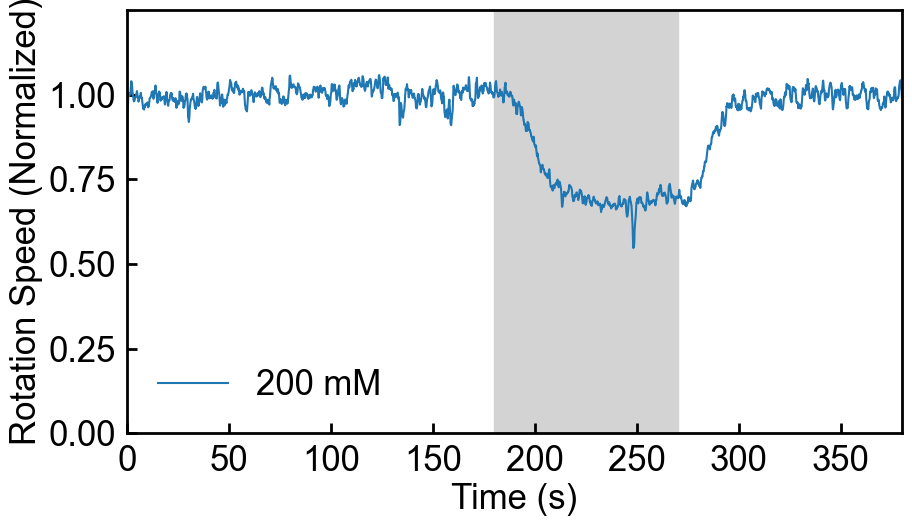

In [88]:
saving_choice=True

custom_legend_labels = ['200 mM']  # Manually set legend labels
# Plotting the sorted data
fig, ax = plt.subplots(figsize=(10, 5.5))

plt.rcParams.update({'font.size': 25})
plt.rcParams['font.family'] = 'Arial'

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

ax.tick_params(axis='x', direction='in', labelsize=25, width=2, length=7.5, pad=8)
ax.tick_params(axis='y', direction='in', labelsize=25, width=2, length=7.5, pad=8)

# Plot sorted data with integer concentrations in the legend
for time, data_norm_filt, conc in zip(sorted_times, sorted_data, sorted_concentrations):
    # Ensure time and data have the same length by trimming the longer one
    if len(time) > len(data_norm_filt):
        time = time[:len(data_norm_filt)]  # Trim time to match data length
    elif len(data_norm_filt) > len(time):
        data_norm_filt = data_norm_filt[:len(time)]  # Trim data to match time length

    # Now plot the data, both time and data have the same length
    ax.plot(time, data_norm_filt, label=f'{int(conc)}' + ' mM')  # Format concentration to int
    #plt.fill_between(time, lower[:len(time)], upper[:len(time)], alpha=0.5)  # Ensure lower and upper bounds match time length

# Finalizing the plot
#plt.xticks((100.0), fontsize=25)
ax.set_xlabel('Time (s)', fontsize=25)
ax.set_ylabel('Rotation Speed (Normalized)', fontsize=25)
ax.set_xlim(0, 380)
ax.set_ylim(0, 1.25)  # Add space below zero

# Custom ticks
ax.set_xticks(np.arange(0, 381, 50))  # Set x-ticks every 50
ticks = np.arange(0, 1.26, 0.25)
ax.set_yticks(ticks[:-1])  # Remove the last tick (1.25)

ax.axvspan(180, 270, color="lightgray", alpha=1)

# Add the legend with sorted concentrations (formatted)
plt.legend(custom_legend_labels, loc='lower left', fontsize=25, frameon=False) # title="[Sucrose] mM", title_fontsize= 20, fontsize=15)
#plt.title('Sorbitol in MB', loc='left', y=0.90, x=0.01, fontsize=20)

# Save the figure
if saving_choice:
    plt.savefig('/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/200mM-with-osmoprotectants/plots/200-osmopro-combined.pdf', dpi=350)  # Save as PDF

# Show the plot
plt.show()

In [89]:
parentDir ='/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/100mM/speeds'
# outputDir = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/100mM/new' #commented out but can be added if wanted
os.chdir(parentDir)

# Initialize the list to store time, data, and sucrose concentrations
all_time = []
all_data = []
concentrations = []

tau_values = {}
t0_values = {}
A_values = {}
tau_inc = {}

# Desired length for all data

target_length = 118000

# Walk through all directories and subdirectories in parentDir
for root, dirs, files in os.walk(parentDir):
    print(root, dirs, files)
    # Filter to only get CSV files in the current directory
    csv_files = [f for f in files if f.endswith('.csv')]

    # If the directory contains CSV files, process them
    if csv_files:
        tau_values[str(root[-5:])] = []
        t0_values[str(root[-5:])] = []
        A_values[str(root[-5:])] = []
        tau_inc[str(root[-5:])] = []
        # Get the time data from the first CSV file to create the time axis
        time = np.array(pd.read_csv(os.path.join(root, csv_files[2]))['Unnamed: 0'][:target_length]) / 300
       
        # Initialize an array to hold data from all CSV files in this folder
        allcells = np.zeros((len(csv_files), 3800))
        
        # Loop through the CSV files in this directory
        for count, fileName in enumerate(csv_files):
            file_path = os.path.join(root, fileName)
            mat_data = pd.read_csv(file_path)
            if root[-5:-2] == "300":
                print(file_path)

            # If the data is shorter than the target length, pad it with zeros
            data = np.array(mat_data['0'])[:target_length]  # Trim data if it's longer

            if len(data) < target_length:
                # Pad with zeros if shorter
                data = np.pad(data, (0, target_length - len(data)), mode='constant', constant_values=np.nan)
            
            # Apply median filtering
            data = scipy.signal.medfilt(data, kernel_size=301) #no med filt for sucrose

            # NOTE FROM NAVISH: MEDFILT MAY INTRODUCE EDGE EFFECTS. WE MIGHT WANT TO USE scipy.ndimage.median_filter INSTEAD.

            new_time, interp_data = bin_data(time, data)

            tau_dec, t0_dec, A_dec, tau_inc_v = calculate_time_constants(new_time, interp_data, str(root[-5:-2]))
            if ((tau_dec > 0) & (tau_dec < 40)) and (A_dec<1.6):
                tau_values[str(root[-5:])] += [tau_dec]
                t0_values[str(root[-5:])] += [t0_dec]
                A_values[str(root[-5:])] += [A_dec]
                tau_inc[str(root[-5:])] += [tau_inc_v]  # Placeholder for tau_inc, not calculated here
            
            allcells[count] = interp_data

        # Calculate the mean and standard deviation for this folder's data
        data_mean = np.average(allcells, axis=0)
        
        time_mult = 10
        data_mean_norm = data_mean / np.average(data_mean[:180 * time_mult])  # Normalize by the first part of the data  #normally 300 for Luis's data

        data_std = np.std(allcells, axis=0) / np.average(data_mean[:180 * time_mult])  #normally 300 for Luis's data

        # Calculate the upper and lower bounds for the shaded area
        upper = data_mean_norm + 0.5 * data_std
        lower = data_mean_norm - 0.5 * data_std

        # Append time, normalized data, and sucrose concentration
        all_time.append(new_time)
        all_data.append(data_mean_norm)

        # Extract sucrose concentration from the directory name
        sucrose_concentration = os.path.basename(root)[:-2]  # Assuming sucrose concentration is in the last 3 characters
        concentrations.append(float(sucrose_concentration))  # Convert to float for sorting

        # # Save the data to a CSV file for this sucrose concentration
        # sucrose_output_dir = os.path.join(outputDir, f"{sucrose_concentration}mM")
        # #os.makedirs(sucrose_output_dir, exist_ok=True)  # Create directory if it doesn't exist

        # # Save time and normalized data to CSV
        # df_output = pd.DataFrame({
        #     'Time': new_time,
        #     'Normalized Data': data_mean_norm
        # })
        # output_file = os.path.join(sucrose_output_dir, f"normalized_data_{sucrose_concentration}mM.csv")
        # #df_output.to_csv(output_file, index=False)

# Sort the concentrations and associated data
sorted_indices = np.argsort(concentrations)
sorted_concentrations = [concentrations[i] for i in sorted_indices]
sorted_data = [all_data[i] for i in sorted_indices]
sorted_times = [all_time[i] for i in sorted_indices]         

/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/100mM/speeds ['100mM'] ['.DS_Store']
/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/100mM/speeds/100mM [] ['.DS_Store', 'freq-cell12.csv', 'freq-cell7.csv', 'freq-cell11.csv', 'freq-cell10.csv', 'freq-cell14.csv', 'freq-cell1.csv', 'freq-cell18.csv', 'freq-cell19.csv', 'freq-cell9.csv', 'freq-cell20.csv', 'freq-cell8.csv']
Error fitting decrease for 100: Optimal parameters not found: Number of calls to function has reached maxfev = 1000.


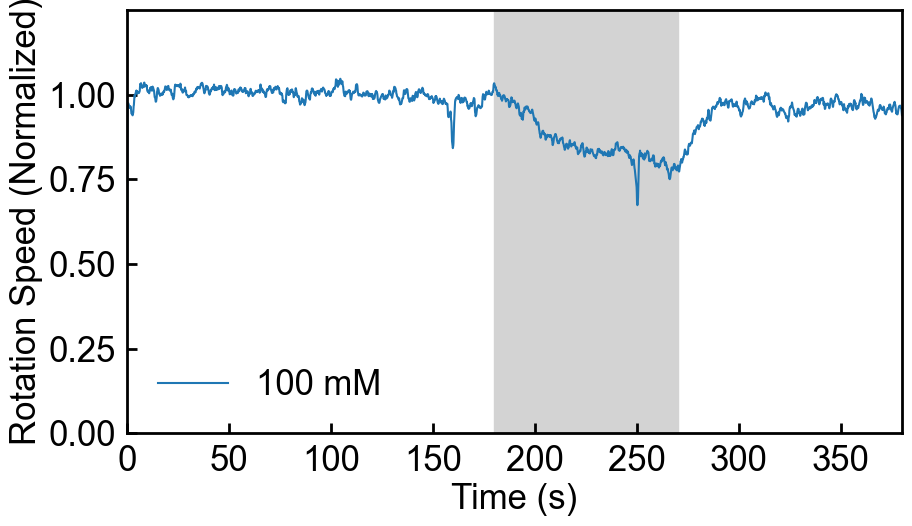

In [90]:
saving_choice=True

custom_legend_labels = ['100 mM']  # Manually set legend labels
# Plotting the sorted data
fig, ax = plt.subplots(figsize=(10, 5.5))

plt.rcParams.update({'font.size': 25})
plt.rcParams['font.family'] = 'Arial'

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

ax.tick_params(axis='x', direction='in', labelsize=25, width=2, length=7.5, pad=8)
ax.tick_params(axis='y', direction='in', labelsize=25, width=2, length=7.5, pad=8)

# Plot sorted data with integer concentrations in the legend
for time, data_norm_filt, conc in zip(sorted_times, sorted_data, sorted_concentrations):
    # Ensure time and data have the same length by trimming the longer one
    if len(time) > len(data_norm_filt):
        time = time[:len(data_norm_filt)]  # Trim time to match data length
    elif len(data_norm_filt) > len(time):
        data_norm_filt = data_norm_filt[:len(time)]  # Trim data to match time length

    # Now plot the data, both time and data have the same length
    ax.plot(time, data_norm_filt, label=f'{int(conc)}' + ' mM')  # Format concentration to int
    #plt.fill_between(time, lower[:len(time)], upper[:len(time)], alpha=0.5)  # Ensure lower and upper bounds match time length

# Finalizing the plot
#plt.xticks((100.0), fontsize=25)
ax.set_xlabel('Time (s)', fontsize=25)
ax.set_ylabel('Rotation Speed (Normalized)', fontsize=25)
ax.set_xlim(0, 380)
ax.set_ylim(0, 1.25)  # Add space below zero

# Custom ticks
ax.set_xticks(np.arange(0, 381, 50))  # Set x-ticks every 50
ticks = np.arange(0, 1.26, 0.25)
ax.set_yticks(ticks[:-1])  # Remove the last tick (1.25)

ax.axvspan(180, 270, color="lightgray", alpha=1)


# Add the legend with sorted concentrations (formatted)
plt.legend(custom_legend_labels, loc='lower left', fontsize=25,frameon=False) # title="[Sucrose] mM", title_fontsize= 20, fontsize=15)
#plt.title('Sorbitol in MB', loc='left', y=0.90, x=0.01, fontsize=20)

# Save the figure
if saving_choice:
    plt.savefig('/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/100mM/plots/100-combined.pdf', dpi=350)  # Save as PDF

# Show the plot
plt.show()

## Sorbitol

In [91]:
parentDir ='/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sorbitol-results/speeds'
outputDir = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sorbitol-results/speeds'
os.chdir(parentDir)

# Initialize the list to store time, data, and sucrose concentrations
all_time = []
all_data = []
concentrations = []

tau_values = {}
t0_values = {}
A_values = {}
tau_inc = {}

# Desired length for all data

target_length = 118000

# Walk through all directories and subdirectories in parentDir
for root, dirs, files in os.walk(parentDir):
    print(root, dirs, files)
    # Filter to only get CSV files in the current directory
    csv_files = [f for f in files if f.endswith('.csv')]

    # If the directory contains CSV files, process them
    if csv_files:
        tau_values[str(root[-5:])] = []
        t0_values[str(root[-5:])] = []
        A_values[str(root[-5:])] = []
        tau_inc[str(root[-5:])] = []
        # Get the time data from the first CSV file to create the time axis
        time = np.array(pd.read_csv(os.path.join(root, csv_files[2]))['Unnamed: 0'][:target_length]) / 300
       
        # Initialize an array to hold data from all CSV files in this folder
        allcells = np.zeros((len(csv_files), 3800))
        
        # Loop through the CSV files in this directory
        for count, fileName in enumerate(csv_files):
            file_path = os.path.join(root, fileName)
            mat_data = pd.read_csv(file_path)
            if root[-5:-2] == "300":
                print(file_path)

            # If the data is shorter than the target length, pad it with zeros
            data = np.array(mat_data['0'])[:target_length]  # Trim data if it's longer

            if len(data) < target_length:
                # Pad with zeros if shorter
                data = np.pad(data, (0, target_length - len(data)), mode='constant', constant_values=np.nan)
            
            # Apply median filtering
            data = scipy.signal.medfilt(data, kernel_size=301) #no med filt for sucrose

            # NOTE FROM NAVISH: MEDFILT MAY INTRODUCE EDGE EFFECTS. WE MIGHT WANT TO USE scipy.ndimage.median_filter INSTEAD.

            new_time, interp_data = bin_data(time, data)

            tau_dec, t0_dec, A_dec, tau_inc_v = calculate_time_constants(new_time, interp_data, str(root[-5:-2]))
            if ((tau_dec > 0) & (tau_dec < 40)) and (A_dec<1.6):
                tau_values[str(root[-5:])] += [tau_dec]
                t0_values[str(root[-5:])] += [t0_dec]
                A_values[str(root[-5:])] += [A_dec]
                tau_inc[str(root[-5:])] += [tau_inc_v]  # Placeholder for tau_inc, not calculated here
            
            allcells[count] = interp_data

        # Calculate the mean and standard deviation for this folder's data
        data_mean = np.average(allcells, axis=0)
        
        time_mult = 10
        data_mean_norm = data_mean / np.average(data_mean[:180 * time_mult])  # Normalize by the first part of the data  #normally 300 for Luis's data

        data_std = np.std(allcells, axis=0) / np.average(data_mean[:180 * time_mult])  #normally 300 for Luis's data

        # Calculate the upper and lower bounds for the shaded area
        upper = data_mean_norm + 0.5 * data_std
        lower = data_mean_norm - 0.5 * data_std

        # Append time, normalized data, and sucrose concentration
        all_time.append(new_time)
        all_data.append(data_mean_norm)

        # Extract sucrose concentration from the directory name
        sucrose_concentration = os.path.basename(root)[:-2]  # Assuming sucrose concentration is in the last 3 characters
        concentrations.append(float(sucrose_concentration))  # Convert to float for sorting

        # Save the data to a CSV file for this sucrose concentration
        sucrose_output_dir = os.path.join(outputDir, f"{sucrose_concentration}mM")
        #os.makedirs(sucrose_output_dir, exist_ok=True)  # Create directory if it doesn't exist

        # Save time and normalized data to CSV
        df_output = pd.DataFrame({
            'Time': new_time,
            'Normalized Data': data_mean_norm
        })
        output_file = os.path.join(sucrose_output_dir, f"normalized_data_{sucrose_concentration}mM.csv")
        #df_output.to_csv(output_file, index=False)

# Sort the concentrations and associated data
sorted_indices = np.argsort(concentrations)
sorted_concentrations = [concentrations[i] for i in sorted_indices]
sorted_data = [all_data[i] for i in sorted_indices]
sorted_times = [all_time[i] for i in sorted_indices]         

/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sorbitol-results/speeds ['500mM', '400mM', '300mM', '200mM'] ['.DS_Store']
/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sorbitol-results/speeds/500mM [] ['freq-500-cell1.csv', 'freq-500-cell3.csv', 'freq-500-cell2.csv', 'freq-500-cell7.csv', 'freq-500-cell5.csv', 'freq-500-cell4.csv', 'freq-500-cell9.csv', 'freq-500-cell8.csv']
/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sorbitol-results/speeds/400mM [] ['freq-400-cell8.csv', 'freq-400-cell4.csv', 'freq-400-cell5.csv', 'freq-400-cell7.csv', 'freq-400-cell6.csv', 'freq-400-cell2.csv', 'freq-400-cell3.csv', 'freq-400-cell1.csv']
/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock

/var/folders/gx/t3n2mgh552n4tvdbx2yzyqdw0000gn/T/ipykernel_4646/2687544286.py:6: RuntimeWarning: overflow encountered in exp
  return B * (1 - np.exp(-(t - 270) / tau)) + D


/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sorbitol-results/speeds/300mM/freq-300-cell8.csv
/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sorbitol-results/speeds/300mM/freq-300-cell10.csv
/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sorbitol-results/speeds/300mM/freq-300-cell11.csv
/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sorbitol-results/speeds/300mM/freq-300-cell9.csv
/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sorbitol-results/speeds/200mM [] ['freq-200-cell5.csv', 'freq-200-cell6.csv', 'freq-200-cell7.csv', 'freq-2

/var/folders/gx/t3n2mgh552n4tvdbx2yzyqdw0000gn/T/ipykernel_4646/2687544286.py:3: RuntimeWarning: overflow encountered in exp
  return A / (1 + np.exp((t-175-t0) / tau)) + C


In [92]:
def equalize_lists(data):
    # Find the maximum length among the lists
    max_length = max(len(lst) for lst in data.values())

    # Equalize lengths by appending np.nan to shorter lists
    equalized_data = {
        key: lst + [np.nan] * (max_length - len(lst)) if len(lst) < max_length else lst
        for key, lst in data.items()
    }

    return equalized_data

In [93]:
print(tau_values)
print(t0_values)
print(A_values)
print(tau_inc)

new_tau_values = equalize_lists(tau_values)
new_t0_values = equalize_lists(t0_values)
new_A_values = equalize_lists(A_values)
new_tau_inc = equalize_lists(tau_inc)

saving_choice = True
if saving_choice:
    pd.DataFrame(new_tau_values).to_csv("/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sorbitol-results/plots/tau_values.csv")
    pd.DataFrame(new_t0_values).to_csv("/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sorbitol-results/plots/t0_values.csv")
    pd.DataFrame(new_A_values).to_csv("/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sorbitol-results/plots/A_values.csv")
    pd.DataFrame(new_tau_inc).to_csv("/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sorbitol-results/plots/tau_inc_values.csv")

{'500mM': [0.3445955696368849, 1.4103731737904055, 3.2859006363334906, 3.3700607918697902, 3.668624154096309, 3.526718984803844, 5.94793045803933, 5.04700814979074], '400mM': [5.5180756772818915, 4.456456733857594, 4.645269366450406, 4.80648508917131, 4.067797284849095, 3.7864018362110983, 4.627650817074251, 7.329040734788306], '300mM': [4.816524218777275, 0.4664070927213851, 7.268791771600577, 4.732691842256752, 2.9512727874192444, 5.334975254798133, 8.179486729641198, 5.53670235367052], '200mM': [3.879217777865397, 9.67905591299555, 2.420663903711462, 8.465387966016147, 0.09375690320722196, 17.16574896631693, 1.8992124605342842, 1.9372468291920129]}
{'500mM': [7.926309092190122, 20.699812148091244, 13.684428875398927, 27.312349511749463, 16.53774722803299, 14.200173220366851, 27.561865331989843, 26.691666351242908], '400mM': [20.93782674603426, 23.778060720227426, 18.862037330227253, 21.94710652147112, 25.04732106868896, 22.736853344064844, 22.77909743295936, 20.238232419266513], '30

## Plot Concentrations of Averages 

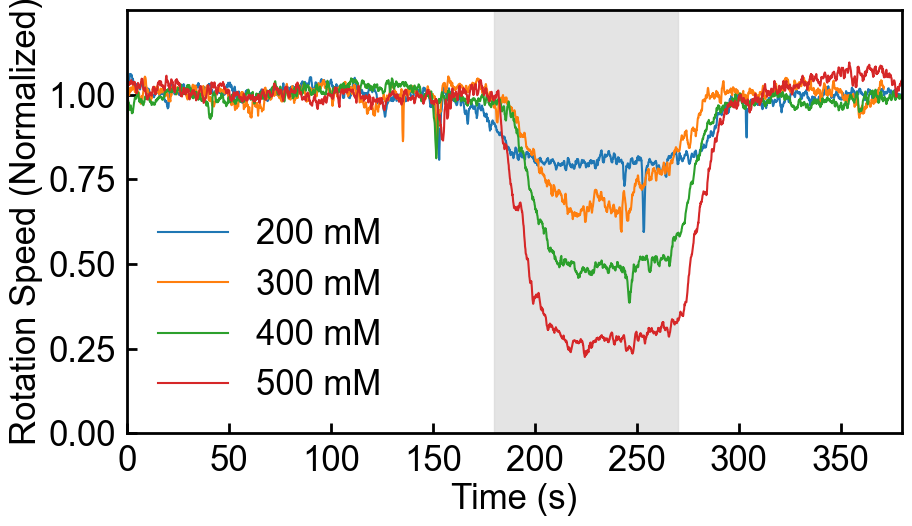

In [94]:
saving_choice=True

custom_legend_labels = ['200 mM', '300 mM', '400 mM', '500 mM']  # Manually set legend labels
# Plotting the sorted data
fig, ax = plt.subplots(figsize=(10, 5.5))

plt.rcParams.update({'font.size': 25})
plt.rcParams['font.family'] = 'Arial'

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

ax.tick_params(axis='x', direction='in', labelsize=25, width=2, length=7.5, pad=8)
ax.tick_params(axis='y', direction='in', labelsize=25, width=2, length=7.5, pad=8)

# Plot sorted data with integer concentrations in the legend
for time, data_norm_filt, conc in zip(sorted_times, sorted_data, sorted_concentrations):
    # Ensure time and data have the same length by trimming the longer one
    if len(time) > len(data_norm_filt):
        time = time[:len(data_norm_filt)]  # Trim time to match data length
    elif len(data_norm_filt) > len(time):
        data_norm_filt = data_norm_filt[:len(time)]  # Trim data to match time length

    # Now plot the data, both time and data have the same length
    ax.plot(time, data_norm_filt, label=f'{int(conc)}' + ' mM')  # Format concentration to int
    #plt.fill_between(time, lower[:len(time)], upper[:len(time)], alpha=0.5)  # Ensure lower and upper bounds match time length

# Finalizing the plot
#plt.xticks((100.0), fontsize=25)
ax.set_xlabel('Time (s)', fontsize=25)
ax.set_ylabel('Rotation Speed (Normalized)', fontsize=25)
ax.set_xlim(0, 380)
ax.set_ylim(0, 1.25)  # Add space below zero

# Custom ticks
ax.set_xticks(np.arange(0, 381, 50))  # Set x-ticks every 50
ticks = np.arange(0, 1.26, 0.25)
ax.set_yticks(ticks[:-1])  # Remove the last tick (1.25)

ax.axvspan(180, 270, color="lightgray", alpha=0.6)

# Add the legend with sorted concentrations (formatted)
plt.legend(custom_legend_labels, loc='lower left', frameon=False, fontsize=25) # title="[Sucrose] mM", title_fontsize= 20, fontsize=15)
#plt.title('Sorbitol in MB', loc='left', y=0.90, x=0.01, fontsize=20)

# Save the figure
if saving_choice:
    plt.savefig("/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sorbitol-results/plots/overall_sorbitol_trend.pdf", dpi=350)  # Save as PDF

# Show the plot
plt.show()

## Plot Tau Decrease Values

Available columns: Index(['concentration mm', 'read1', 'read2', 'avg_osmolarity',
       'change_in_osmolarity'],
      dtype='object')
Change in Osmolarity: [216.5 379.5 531.5 788. ]
500mM
400mM
300mM
200mM


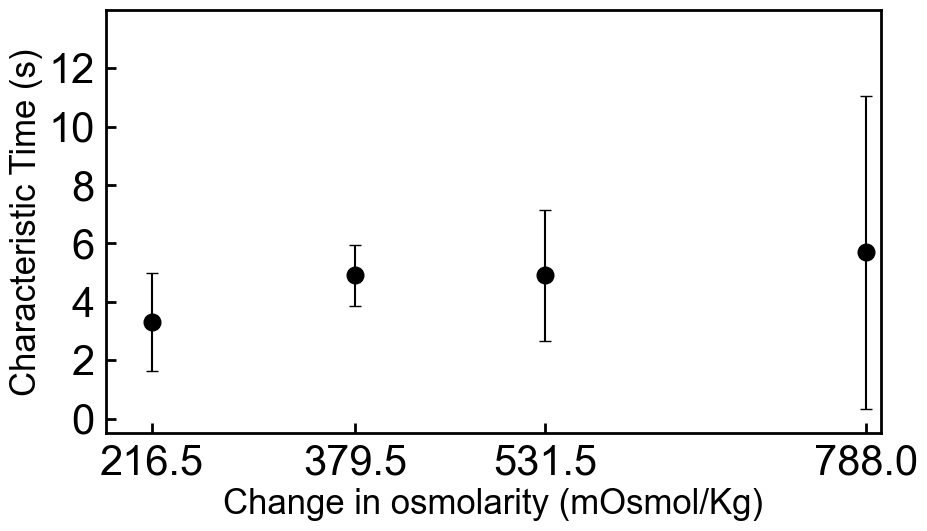

Average characteristic time: 4.708 s
Standard deviation of characteristic times: 0.860 s


In [95]:


fig, ax = plt.subplots(figsize=(10, 5.5))

plt.rcParams.update({'font.size': 30})
plt.rcParams['font.family'] = 'Arial'

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

ax.tick_params(axis='x', direction='in', labelsize=30, width=2, length=7.5, pad=8)
ax.tick_params(axis='y', direction='in', labelsize=30, width=2, length=7.5, pad=8)

file = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sorbitol-results/plots/tau_values.csv'

# --- MODIFIED OSMOLARITY READING ---
# Path to the Excel file
excel_path = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Osmolarity-mesurments/sorbitol.xlsx'

df_osmo = pd.read_excel(excel_path)

# Normalize column names: lowercase, no leading/trailing spaces
df_osmo.columns = df_osmo.columns.str.strip().str.lower()

# Check what columns exist
print("Available columns:", df_osmo.columns)

# Identify the read columns (allow space in name like 'read 1')
read_cols = [col for col in df_osmo.columns if 'read' in col]

if len(read_cols) < 2:
    raise ValueError("Could not find two 'Read' columns in the Excel file.")

# Average them
df_osmo['avg_osmolarity'] = df_osmo[read_cols[:2]].mean(axis=1)

# Calculate change relative to the first row
df_osmo['change_in_osmolarity'] = df_osmo['avg_osmolarity'] - df_osmo['avg_osmolarity'].iloc[0]

# Save back to the Excel file (overwrite)
df_osmo.to_excel(excel_path, index=False)

# Extract change values for plotting (excluding baseline row)
osmotic_shock_values = df_osmo['change_in_osmolarity'].iloc[1:].values
print("Change in Osmolarity:", osmotic_shock_values)

# --- MAIN PLOTTING SECTION ---
# --- MAIN PLOTTING SECTION ---
means = []
stds = []
concentrations = []
count = 0  # Initialize count

if file.endswith(".csv"):
    data = pd.read_csv(file)
    for column in data.keys():
        if column != "Unnamed: 0":
            print(column)
            standard_dev = np.std(data[column])
            mean = np.mean(data[column])

            # Use regex to safely extract number from column label
            match = re.search(r'\d+', column)
            if match:
                concentrations.append(int(match.group()))
            else:
                print(f"Skipping column due to invalid label: {column}")
                continue

            # ax.scatter([osmotic_shock_values[3 - count]] * len(data[column]), data[column],
            #            color='black', alpha=0.2)
            means.append(mean)
            stds.append(standard_dev)
            count += 1

    ax.errorbar(osmotic_shock_values, means, yerr=stds, marker="o", markeredgecolor='k',
                markersize=12, linestyle='None', color='black', ecolor='black', capsize=4)
    ax.set_xticks(osmotic_shock_values)

    # Finalizing the plot
    ax.set_xlabel('Change in osmolarity (mOsmol/Kg)')
    ax.set_ylabel('Characteristic Time (s)')
    ax.set_xlim(180, 800)
    #ax.set_yticks([-10.5, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6])
    ax.set_ylim(-0.5, 14)
    ax.set_yticks(np.arange(0, 14, 2))
    #plt.title('Sorbitol in MB', loc='left', y=0.90, x=.75, fontsize=20)

    # Save and show plot
    plt.savefig('/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sorbitol-results/plots/tau_values_plot.pdf', dpi=350)
    plt.show()
    
    # --- SAVE AVERAGE TO TEXT FILE ---
       # --- SAVE AVERAGE AND STD OF MEANS TO TEXT FILE ---
    avg_tau = np.mean(means)
    std_tau = np.std(means)

    output_df = pd.DataFrame({
        "Change in Osmolarity (mOsmol/Kg)": osmotic_shock_values,
        "Mean Characteristic Time (s)": means,
        "Std Dev": stds
    })

    # Append a final row with overall average and std dev
    avg_row = pd.DataFrame({
        "Change in Osmolarity (mOsmol/Kg)": ["Average"],
        "Mean Characteristic Time (s)": [avg_tau],
        "Std Dev": [std_tau]
    })

    output_df = pd.concat([output_df, avg_row], ignore_index=True)
    output_df.to_csv('/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sorbitol-results/plots/tau_values_summary.txt', sep='\t', index=False)

    print(f"Average characteristic time: {avg_tau:.3f} s")
    print(f"Standard deviation of characteristic times: {std_tau:.3f} s")


Change in Osmolarity: [216.5 379.5 531.5 788. ]


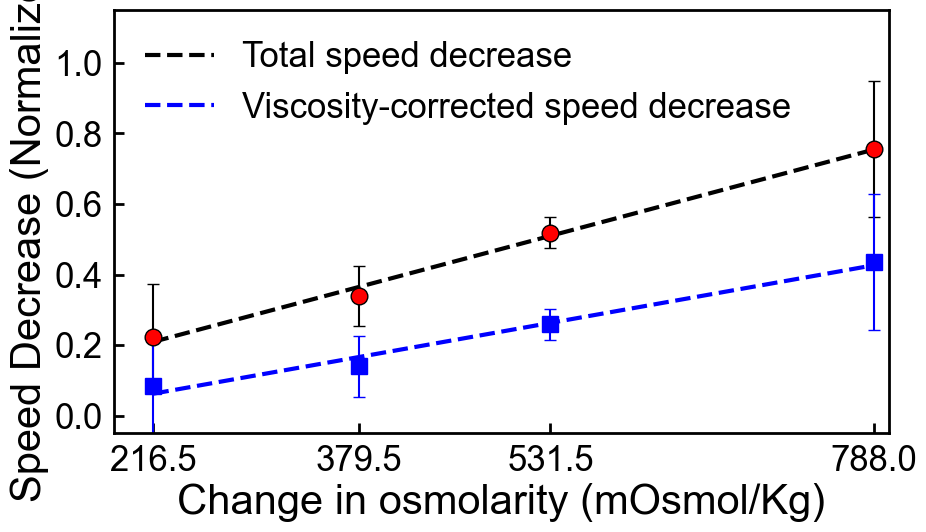

In [96]:

from scipy.stats import linregress

# Set working directory
parentDir = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sorbitol-results/plots/'
os.chdir(parentDir)

file = os.path.join(parentDir, "A_values.csv")
excel_path = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Osmolarity-mesurments/sorbitol.xlsx'

# Plot setup
fig, ax = plt.subplots(figsize=(10, 5.5))
plt.rcParams.update({'font.size': 25})
plt.rcParams['font.family'] = 'Arial'

for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(2)

ax.tick_params(axis='x', direction='in', labelsize=25, width=2, length=7.5, pad=8)
ax.tick_params(axis='y', direction='in', labelsize=25, width=2, length=7.5, pad=8)

# Load osmolarity data
df_osmo = pd.read_excel(excel_path)
df_osmo.columns = df_osmo.columns.str.strip().str.lower()
read_cols = [col for col in df_osmo.columns if 'read' in col]

if len(read_cols) < 2:
    raise ValueError("Could not find two 'Read' columns in the Excel file.")

df_osmo['avg_osmolarity'] = df_osmo[read_cols[:2]].mean(axis=1)
df_osmo['change_in_osmolarity'] = df_osmo['avg_osmolarity'] - df_osmo['avg_osmolarity'].iloc[0]
df_osmo.to_excel(excel_path, index=False)

osmotic_shock_values = df_osmo['change_in_osmolarity'].iloc[1:].values
print("Change in Osmolarity:", osmotic_shock_values)

# --- Process A values ---
means = []
stds = []
concentrations = []
cleaned_columns = []

if file.endswith(".csv"):
    data = pd.read_csv(file)
    valid_columns = [col for col in data.columns if col != "Unnamed: 0"]

    for column in valid_columns:
        match = re.search(r'(\d+)', column)
        if match:
            concentration = int(match.group())
            cleaned_columns.append((concentration, column))
        else:
            print(f"⚠️ Skipping column due to invalid label: {column}")

    # Sort by numeric concentration
    cleaned_columns.sort(key=lambda x: x[0])

    if len(cleaned_columns) != len(osmotic_shock_values):
        raise ValueError(f"❌ Mismatch between data columns ({len(cleaned_columns)}) and osmotic shock values ({len(osmotic_shock_values)}).")

    for i, (conc, col_name) in enumerate(cleaned_columns):
        col_data = data[col_name]
        means.append(np.mean(col_data))
        stds.append(np.std(col_data))
        concentrations.append(conc)

    # --- Plot Total Speed Decrease ---
    ax.errorbar(
        osmotic_shock_values, means, yerr=stds,
        marker="o", markeredgecolor='k', markersize=12,
        linestyle='None', color='red', ecolor='black', capsize=4)
    #     label='Total Speed Decrease'
    # )

    ax.set_xticks(osmotic_shock_values)
    ax.set_xlabel('Change in osmolarity (mOsmol/Kg)')
    ax.set_ylabel('Speed Decrease (Normalized)')
    ax.set_ylim(-0.05, 1.15)
    ax.set_xlim(185, 800)
    ax.set_yticks(np.arange(0.0, 1.15, 0.2))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}'))

    # === Linear Fit for Total Speed Decrease ===
    x_data = np.array(osmotic_shock_values)
    y_data = np.array(means)

    slope, intercept, r_value, p_value, std_err = linregress(x_data, y_data)
    x_fit = np.linspace(min(x_data), max(x_data), 1000)
    y_fit = slope * x_fit + intercept
    ax.plot(x_fit, y_fit, linestyle="--", color="black", linewidth=3, label = 'Total speed decrease')

    # === Viscosity Correction for Sorbitol ===
    viscosity_dict = {
        200: 0.14,
        300: 0.20,
        400: 0.26,
        500: 0.32
    }

    viscosities = [viscosity_dict.get(c, 0) for c in concentrations]
    diff_values = np.array(means) - np.array(viscosities)

    ax.errorbar(
        osmotic_shock_values, diff_values, yerr=stds,
        marker="s", markeredgecolor='blue', markersize=12,
        linestyle='None', color='blue', ecolor='blue', capsize=4)
    #     label='Remaining Speed Decrease'
    # )

    # === Linear Fit for Viscosity-Corrected Data ===
    slope_diff, intercept_diff, r_value_diff, p_value_diff, std_err_diff = linregress(x_data, diff_values)
    y_fit_diff = slope_diff * x_fit + intercept_diff
    ax.plot(x_fit, y_fit_diff, linestyle="--", color="blue", linewidth=3, label='Viscosity-corrected speed decrease')

    # Add legend
    ax.legend(loc='upper left', frameon = False)

        # === Linear Fit for Viscosity-Only Data (not plotted) ===
    viscosity_values = np.array(viscosities)
    slope_visc, intercept_visc, r_value_visc, p_value_visc, std_err_visc = linregress(x_data, viscosity_values)

    # Save all fit stats
    stats_output_path = os.path.join(parentDir, "sorbitol_A_linear_fit_stats.txt")
    with open(stats_output_path, 'w') as f:
        f.write("Linear Fit Statistics - Total Speed Decrease\n")
        f.write("===========================================\n")
        f.write(f"Slope: {slope:.6f}\nIntercept: {intercept:.6f}\nR-squared: {r_value**2:.6f}\n")
        f.write(f"P-value: {p_value:.6e}\nStandard Error: {std_err:.6f}\n\n")

        f.write("Linear Fit Statistics - Remaining Speed Decrease\n")
        f.write("===============================================\n")
        f.write(f"Slope: {slope_diff:.6f}\nIntercept: {intercept_diff:.6f}\nR-squared: {r_value_diff**2:.6f}\n")
        f.write(f"P-value: {p_value_diff:.6e}\nStandard Error: {std_err_diff:.6f}\n\n")

        f.write("Linear Fit Statistics - Viscosity-Only Speed Decrease\n")
        f.write("====================================================\n")
        f.write(f"Slope: {slope_visc:.6f}\nIntercept: {intercept_visc:.6f}\nR-squared: {r_value_visc**2:.6f}\n")
        f.write(f"P-value: {p_value_visc:.6e}\nStandard Error: {std_err_visc:.6f}\n")

    # Save figure
    plt.savefig(os.path.join(parentDir, "sorbitol_A_linear_fit.pdf"), dpi=350)
    plt.show()

## Sodium

In [97]:
parentDir = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sodium-phosphate-results/speeds'
outputDir = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sodium-phosphate-results/speeds'
os.chdir(parentDir)

# Initialize the list to store time, data, and sucrose concentrations
all_time = []
all_data = []
concentrations = []

tau_values = {}
t0_values = {}
A_values = {}
tau_inc = {}

# Desired length for all data

target_length = 118000

# Walk through all directories and subdirectories in parentDir
for root, dirs, files in os.walk(parentDir):
    print(root, dirs, files)
    # Filter to only get CSV files in the current directory
    csv_files = [f for f in files if f.endswith('.csv')]

    # If the directory contains CSV files, process them
    if csv_files:
        tau_values[str(root[-5:])] = []
        t0_values[str(root[-5:])] = []
        A_values[str(root[-5:])] = []
        tau_inc[str(root[-5:])] = []
        # Get the time data from the first CSV file to create the time axis
        time = np.array(pd.read_csv(os.path.join(root, csv_files[2]))['Unnamed: 0'][:target_length]) / 300
       
        # Initialize an array to hold data from all CSV files in this folder
        allcells = np.zeros((len(csv_files), 3800))
        
        # Loop through the CSV files in this directory
        for count, fileName in enumerate(csv_files):
            file_path = os.path.join(root, fileName)
            mat_data = pd.read_csv(file_path)
            if root[-5:-2] == "300":
                print(file_path)

            # If the data is shorter than the target length, pad it with zeros
            data = np.array(mat_data['0'])[:target_length]  # Trim data if it's longer

            if len(data) < target_length:
                # Pad with zeros if shorter
                data = np.pad(data, (0, target_length - len(data)), mode='constant', constant_values=np.nan)
            
            # Apply median filtering
            data = scipy.signal.medfilt(data, kernel_size=301) #no med filt for sucrose

            new_time, interp_data = bin_data(time, data)

            tau_dec, t0_dec, A_dec, tau_inc_v = calculate_time_constants(new_time, interp_data, str(root[-5:-2]))
            if ((tau_dec > 0) & (tau_dec < 40)) and (A_dec<1.6):
                tau_values[str(root[-5:])] += [tau_dec]
                t0_values[str(root[-5:])] += [t0_dec]
                A_values[str(root[-5:])] += [A_dec]
                tau_inc[str(root[-5:])] += [tau_inc_v]  # Placeholder for tau_inc, not calculated here
            
            allcells[count] = interp_data

        # Calculate the mean and standard deviation for this folder's data
        data_mean = np.average(allcells, axis=0)
        
        time_mult = 10
        data_mean_norm = data_mean / np.average(data_mean[:180 * time_mult])  # Normalize by the first part of the data  #normally 300 for Luis's data

        data_std = np.std(allcells, axis=0) / np.average(data_mean[:180 * time_mult])  #normally 300 for Luis's data

        # Calculate the upper and lower bounds for the shaded area
        upper = data_mean_norm + 0.5 * data_std
        lower = data_mean_norm - 0.5 * data_std

        # Append time, normalized data, and sucrose concentration
        all_time.append(new_time)
        all_data.append(data_mean_norm)

        # Extract sucrose concentration from the directory name
        sucrose_concentration = os.path.basename(root)[:-2]  # Assuming sucrose concentration is in the last 3 characters
        concentrations.append(float(sucrose_concentration))  # Convert to float for sorting

        # Save the data to a CSV file for this sucrose concentration
        sucrose_output_dir = os.path.join(outputDir, f"{sucrose_concentration}mM")
        #os.makedirs(sucrose_output_dir, exist_ok=True)  # Create directory if it doesn't exist

        # Save time and normalized data to CSV
        df_output = pd.DataFrame({
            'Time': new_time,
            'Normalized Data': data_mean_norm
        })
        output_file = os.path.join(sucrose_output_dir, f"normalized_data_{sucrose_concentration}mM.csv")
        #df_output.to_csv(output_file, index=False)

# Sort the concentrations and associated data
sorted_indices = np.argsort(concentrations)
sorted_concentrations = [concentrations[i] for i in sorted_indices]
sorted_data = [all_data[i] for i in sorted_indices]
sorted_times = [all_time[i] for i in sorted_indices]

/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sodium-phosphate-results/speeds ['500mM', '400mM', '300mM', '200mM'] ['.DS_Store']
/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sodium-phosphate-results/speeds/500mM [] ['freq-500-cell1.csv', 'freq-500-cell3.csv', 'freq-500-cell2.csv', 'freq-500-cell6.csv', 'freq-500-cell7.csv', 'freq-500-cell5.csv', 'freq-500-cell4.csv', 'freq-500-cell9.csv', 'freq-500-cell8.csv', 'freq-500-cell10.csv']
/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sodium-phosphate-results/speeds/400mM [] ['freq-400-cell8.csv', 'freq-400-cell9.csv', 'freq-400-cell13.csv', 'freq-400-cell6.csv', 'freq-400-cell16.csv', 'freq-400-cell17.csv', 'freq-400-cell3.csv', 'freq-400-cell1.csv', 'freq-400-cell15

/var/folders/gx/t3n2mgh552n4tvdbx2yzyqdw0000gn/T/ipykernel_4646/2687544286.py:3: RuntimeWarning: overflow encountered in exp
  return A / (1 + np.exp((t-175-t0) / tau)) + C


/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sodium-phosphate-results/speeds/300mM/freq-300-cell13.csv
/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sodium-phosphate-results/speeds/300mM/freq-300-cell12.csv
/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sodium-phosphate-results/speeds/300mM/freq-300-cell15.csv
/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sodium-phosphate-results/speeds/300mM/freq-300-cell14.csv
/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sodium-phosphate-results/speeds/200mM [] ['freq-200-cell9.csv', 'freq-200

In [98]:
def equalize_lists(data):
    # Find the maximum length among the lists
    max_length = max(len(lst) for lst in data.values())

    # Equalize lengths by appending np.nan to shorter lists
    equalized_data = {
        key: lst + [np.nan] * (max_length - len(lst)) if len(lst) < max_length else lst
        for key, lst in data.items()
    }

    return equalized_data

In [99]:
print(tau_values)
print(t0_values)
print(A_values)
print(tau_inc)

new_tau_values = equalize_lists(tau_values)
new_t0_values = equalize_lists(t0_values)
new_A_values = equalize_lists(A_values)
new_tau_inc = equalize_lists(tau_inc)

saving_choice = True
if saving_choice:
    pd.DataFrame(new_tau_values).to_csv("/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sodium-phosphate-results/plots/tau_values.csv")
    pd.DataFrame(new_t0_values).to_csv("/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sodium-phosphate-results/plots/t0_values.csv")
    pd.DataFrame(new_A_values).to_csv("/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sodium-phosphate-results/plots/A_values.csv")
    pd.DataFrame(new_tau_inc).to_csv("/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sodium-phosphate-results/plots/tau_inc_values.csv")

{'500mM': [3.7097378553178526, 4.8530745876708234, 5.493122995731222, 3.698086881401434, 1.4103731737904055, 7.3564207128993395, 6.190790230192557, 3.526718984803844, 3.668624154096309, 3.2859006363334906], '400mM': [7.898907485778265, 5.086229119287077, 1.553527350018371, 4.875837605542483, 6.301320033587672, 9.388327449473273, 4.329615996967115, 2.1241910619855364, 6.506023859581094, 5.598690389603262], '300mM': [6.580578225124305, 3.4374681416748873, 3.111834916385628, 4.706566932837054, 6.791254048282994, 3.3829620116807586, 4.51013244765515, 5.988365822108425, 2.478781124641035], '200mM': [5.519540172119901, 4.357621056324416, 12.171813544019686, 9.673943071008521, 4.031028526249811, 6.912208762054573, 1.5383724903064933, 18.802023010384733, 4.841440942218815]}
{'500mM': [26.007159570564852, 36.92892561824245, 38.662019265981066, 23.81871032016498, 20.699812148091244, 17.315262142460547, 24.450649718080353, 14.200173220366851, 16.53774722803299, 13.684428875398927], '400mM': [22.5

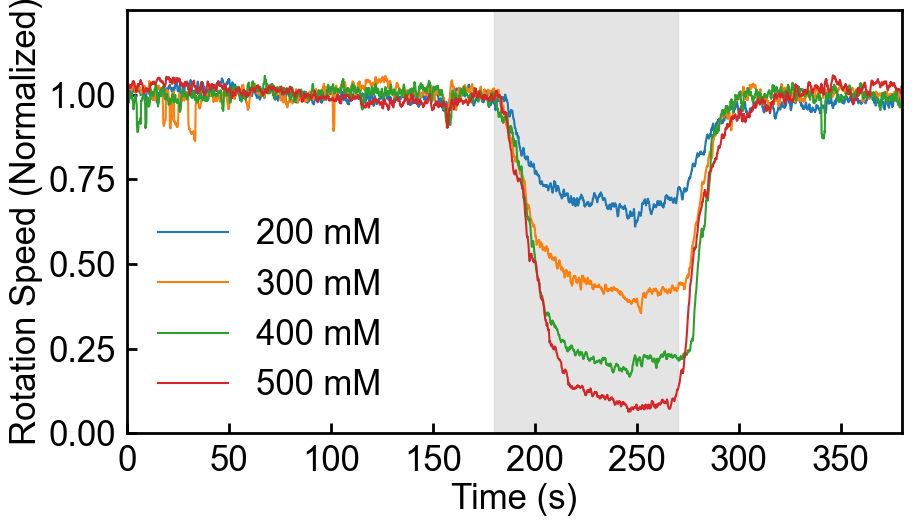

In [100]:
saving_choice=True

custom_legend_labels = ['200 mM', '300 mM', '400 mM', '500 mM']  # Manually set legend labels
# Plotting the sorted data
fig, ax = plt.subplots(figsize=(10, 5.5))

plt.rcParams.update({'font.size': 25})
plt.rcParams['font.family'] = 'Arial'

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

ax.tick_params(axis='x', direction='in', labelsize=25, width=2, length=7.5, pad=8)
ax.tick_params(axis='y', direction='in', labelsize=25, width=2, length=7.5, pad=8)

# Plot sorted data with integer concentrations in the legend
for time, data_norm_filt, conc in zip(sorted_times, sorted_data, sorted_concentrations):
    # Ensure time and data have the same length by trimming the longer one
    if len(time) > len(data_norm_filt):
        time = time[:len(data_norm_filt)]  # Trim time to match data length
    elif len(data_norm_filt) > len(time):
        data_norm_filt = data_norm_filt[:len(time)]  # Trim data to match time length

    # Now plot the data, both time and data have the same length
    ax.plot(time, data_norm_filt, label=f'{int(conc)}' + ' mM')  # Format concentration to int
    #plt.fill_between(time, lower[:len(time)], upper[:len(time)], alpha=0.5)  # Ensure lower and upper bounds match time length

# Finalizing the plot
#plt.xticks((100.0), fontsize=25)
ax.set_xlabel('Time (s)', fontsize=25)
ax.set_ylabel('Rotation Speed (Normalized)', fontsize=25)
ax.set_xlim(0, 380)
ax.set_ylim(0, 1.25)  # Add space below zero

# Custom ticks
ax.set_xticks(np.arange(0, 381, 50))  # Set x-ticks every 50
ticks = np.arange(0, 1.26, 0.25)
ax.set_yticks(ticks[:-1])  # Remove the last tick (1.25)

ax.axvspan(180, 270, color="lightgray", alpha=0.6)

# Add the legend with sorted concentrations (formatted)
plt.legend(custom_legend_labels, loc='lower left', frameon = False,  fontsize=25) # title="[Sucrose] mM", title_fontsize= 20, fontsize=15)

#plt.title('Sucrose in SPB', loc='left', y=0.90, x=0.01, fontsize=20)

# Save the figure
if saving_choice:
    plt.savefig('/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sodium-phosphate-results/plots/overall_trend.pdf', dpi=350)  # Save as PDF

# Show the plot
plt.show()

Available columns: Index(['concentration mm', 'read1', 'read2', 'avg_osmolarity',
       'change_in_osmolarity'],
      dtype='object')
Change in Osmolarity: [226.5 412.5 620.5 759. ]
500mM
400mM
300mM
200mM


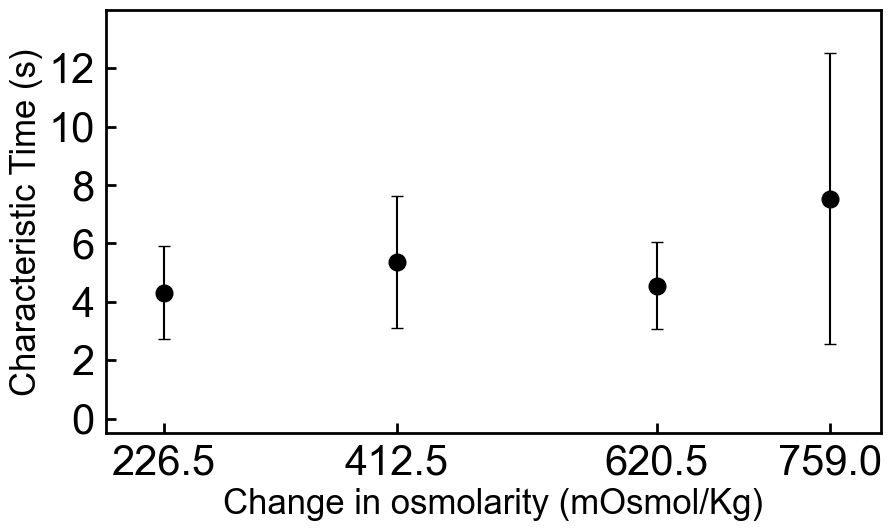

Average characteristic time: 5.445 s
Standard deviation of characteristic times: 1.270 s


In [101]:

fig, ax = plt.subplots(figsize=(10, 5.5))

plt.rcParams.update({'font.size': 30})
plt.rcParams['font.family'] = 'Arial'

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

ax.tick_params(axis='x', direction='in', labelsize=30, width=2, length=7.5, pad=8)
ax.tick_params(axis='y', direction='in', labelsize=30, width=2, length=7.5, pad=8)

file = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sodium-phosphate-results/plots/tau_values.csv'

# --- MODIFIED OSMOLARITY READING ---
# Path to the Excel file
excel_path = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Osmolarity-mesurments/sodium.xlsx'
df_osmo = pd.read_excel(excel_path)

# Normalize column names: lowercase, no leading/trailing spaces
df_osmo.columns = df_osmo.columns.str.strip().str.lower()

# Check what columns exist
print("Available columns:", df_osmo.columns)

# Identify the read columns (allow space in name like 'read 1')
read_cols = [col for col in df_osmo.columns if 'read' in col]

if len(read_cols) < 2:
    raise ValueError("Could not find two 'Read' columns in the Excel file.")

# Average them
df_osmo['avg_osmolarity'] = df_osmo[read_cols[:2]].mean(axis=1)

# Calculate change relative to the first row
df_osmo['change_in_osmolarity'] = df_osmo['avg_osmolarity'] - df_osmo['avg_osmolarity'].iloc[0]

# Save back to the Excel file (overwrite)
df_osmo.to_excel(excel_path, index=False)

# Extract change values for plotting (excluding baseline row)
osmotic_shock_values = df_osmo['change_in_osmolarity'].iloc[1:].values
print("Change in Osmolarity:", osmotic_shock_values)

# --- MAIN PLOTTING SECTION ---
# --- MAIN PLOTTING SECTION ---
means = []
stds = []
concentrations = []
count = 0  # Initialize count

if file.endswith(".csv"):
    data = pd.read_csv(file)
    for column in data.keys():
        if column != "Unnamed: 0":
            print(column)
            standard_dev = np.std(data[column])
            mean = np.mean(data[column])

            # Use regex to safely extract number from column label
            match = re.search(r'\d+', column)
            if match:
                concentrations.append(int(match.group()))
            else:
                print(f"Skipping column due to invalid label: {column}")
                continue

            # ax.scatter([osmotic_shock_values[3 - count]] * len(data[column]), data[column],
            #            color='black', alpha=0.2)
            means.append(mean)
            stds.append(standard_dev)
            count += 1

    ax.errorbar(osmotic_shock_values, means, yerr=stds, marker="o", markeredgecolor='k',
                markersize=12, linestyle='None', color='black', ecolor='black', capsize=4)
    ax.set_xticks(osmotic_shock_values)

    # Finalizing the plot
    ax.set_xlabel('Change in osmolarity (mOsmol/Kg)')
    ax.set_ylabel('Characteristic Time (s)')
    ax.set_xlim(180, 800)
    #ax.set_yticks([-10.5, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6])
    ax.set_ylim(-0.5, 14)
    ax.set_yticks(np.arange(0, 14, 2))
    #plt.title('Sucrose in SPB', loc='left', y=0.90, x=.72, fontsize=20)

    # Save and show plot
    plt.savefig('/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sodium-phosphate-results/plots/tau.pdf', dpi=350)
    plt.show()
    
    # --- SAVE AVERAGE TO TEXT FILE ---
       # --- SAVE AVERAGE AND STD OF MEANS TO TEXT FILE ---
    avg_tau = np.mean(means)
    std_tau = np.std(means)

    output_df = pd.DataFrame({
        "Change in Osmolarity (mOsmol/Kg)": osmotic_shock_values,
        "Mean Characteristic Time (s)": means,
        "Std Dev": stds
    })

    # Append a final row with overall average and std dev
    avg_row = pd.DataFrame({
        "Change in Osmolarity (mOsmol/Kg)": ["Average"],
        "Mean Characteristic Time (s)": [avg_tau],
        "Std Dev": [std_tau]
    })

    output_df = pd.concat([output_df, avg_row], ignore_index=True)
    output_df.to_csv('/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sodium-phosphate-results/plots/tau_summary.txt', sep='\t', index=False)

    print(f"Average characteristic time: {avg_tau:.3f} s")
    print(f"Standard deviation of characteristic times: {std_tau:.3f} s")


Change in Osmolarity: [226.5 412.5 620.5 759. ]
Total Speed Decrease fit slope: 0.0010
R-squared: 0.9934
Remaining Speed Decrease fit slope: 0.0005
R-squared: 0.9487
Stats saved to: /Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sodium-phosphate-results/plots/A_values_linear_fit_stats.txt


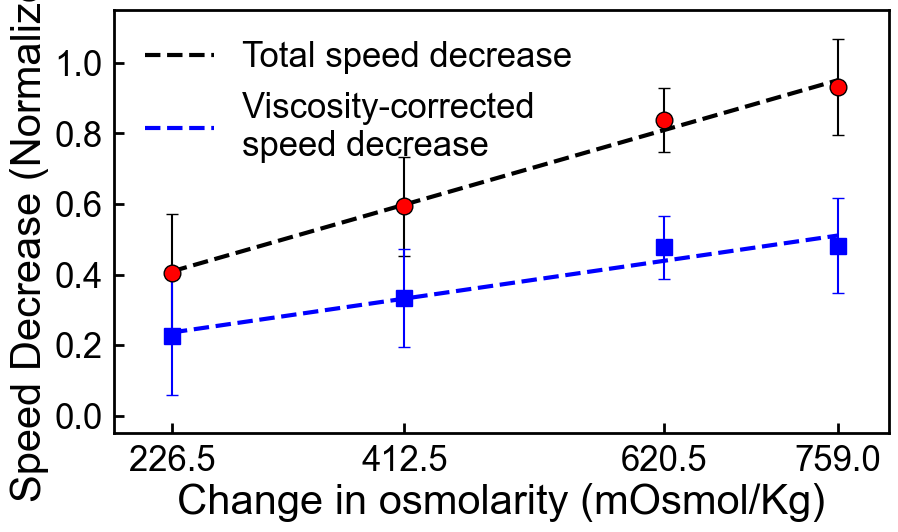

In [102]:

from scipy.stats import linregress

# Set working directory
parentDir = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/sodium-phosphate-results/plots'
os.chdir(parentDir)

file = os.path.join(parentDir, "A_values.csv")
excel_path = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Osmolarity-mesurments/sodium.xlsx'

# Plot setup
fig, ax = plt.subplots(figsize=(10, 5.5))
plt.rcParams.update({'font.size': 25})
plt.rcParams['font.family'] = 'Arial'

for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(2)

ax.tick_params(axis='x', direction='in', labelsize=25, width=2, length=7.5, pad=8)
ax.tick_params(axis='y', direction='in', labelsize=25, width=2, length=7.5, pad=8)

# Load osmolarity data
df_osmo = pd.read_excel(excel_path)
df_osmo.columns = df_osmo.columns.str.strip().str.lower()
read_cols = [col for col in df_osmo.columns if 'read' in col]

if len(read_cols) < 2:
    raise ValueError("Could not find two 'Read' columns in the Excel file.")

df_osmo['avg_osmolarity'] = df_osmo[read_cols[:2]].mean(axis=1)
df_osmo['change_in_osmolarity'] = df_osmo['avg_osmolarity'] - df_osmo['avg_osmolarity'].iloc[0]
df_osmo.to_excel(excel_path, index=False)

osmotic_shock_values = df_osmo['change_in_osmolarity'].iloc[1:].values
print("Change in Osmolarity:", osmotic_shock_values)

# --- Process A values ---
means = []
stds = []
concentrations = []
cleaned_columns = []

if file.endswith(".csv"):
    data = pd.read_csv(file)
    valid_columns = [col for col in data.columns if col != "Unnamed: 0"]

    for column in valid_columns:
        match = re.search(r'(\d+)', column)
        if match:
            concentration = int(match.group())
            cleaned_columns.append((concentration, column))
        else:
            print(f"⚠️ Skipping column due to invalid label: {column}")

    # Sort by numeric concentration just to be safe
    cleaned_columns.sort(key=lambda x: x[0])

    if len(cleaned_columns) != len(osmotic_shock_values):
        raise ValueError(
            f"❌ Mismatch between cleaned data columns ({len(cleaned_columns)}) "
            f"and osmotic shock values ({len(osmotic_shock_values)})."
        )

    for i, (conc, col_name) in enumerate(cleaned_columns):
        col_data = data[col_name]
        means.append(np.mean(col_data))
        stds.append(np.std(col_data))
        concentrations.append(conc)

        # Optional: individual dots
        # ax.scatter([osmotic_shock_values[i]] * len(col_data), col_data, color='black', alpha=0.2)

    # --- Plot Total Speed Decrease ---
    ax.errorbar(
        osmotic_shock_values, means, yerr=stds,
        marker="o", markeredgecolor='k', markersize=12,
        linestyle='None', color='red', ecolor='black', capsize=4)
    #     label='Total Speed Decrease'
    # )

    ax.set_xticks(osmotic_shock_values)
    ax.set_xlabel('Change in osmolarity (mOsmol/Kg)')
    ax.set_ylabel('Speed Decrease (Normalized)')
    ax.set_ylim(-0.05, 1.15)
    ax.set_xlim(180, 800)

    # === Linear Fit for Total Speed Decrease ===
    x_data = np.array(osmotic_shock_values)
    y_data = np.array(means)

    slope, intercept, r_value, p_value, std_err = linregress(x_data, y_data)
    x_fit = np.linspace(min(x_data), max(x_data), 1000)
    y_fit = slope * x_fit + intercept
    ax.plot(x_fit, y_fit, linestyle="--", color="black", linewidth=3, label='Total speed decrease')

    # === Viscosity Correction (0 for sodium) ===
    viscosity_dict = {
        200: 0.18,
        300: 0.26,
        400: 0.36,
        500: 0.45
    }

    viscosities = [viscosity_dict.get(c, 0) for c in concentrations]
    diff_values = np.array(means) - np.array(viscosities)

    ax.errorbar(
        osmotic_shock_values, diff_values, yerr=stds,
        marker="s", markeredgecolor='blue', markersize=12,
        linestyle='None', color='blue', ecolor='blue', capsize=4)
    #     label='Remaining Speed Decrease'
    # )

    # === Linear Fit for Remaining Speed Decrease ===
    slope_diff, intercept_diff, r_value_diff, p_value_diff, std_err_diff = linregress(x_data, diff_values)
    y_fit_diff = slope_diff * x_fit + intercept_diff
    ax.plot(x_fit, y_fit_diff, linestyle="--", color="blue", linewidth=3, label='Viscosity-corrected \nspeed decrease')

    # Add legend
    ax.legend(loc='upper left', frameon = False)

    # Print stats
    print(f"Total Speed Decrease fit slope: {slope:.4f}")
    print(f"R-squared: {r_value**2:.4f}")
    print(f"Remaining Speed Decrease fit slope: {slope_diff:.4f}")
    print(f"R-squared: {r_value_diff**2:.4f}")

    # Save stats to file
    stats_output_path = os.path.join(parentDir, "A_values_linear_fit_stats.txt")
    with open(stats_output_path, 'w') as f:
        f.write("Linear Fit Statistics - Total Speed Decrease\n")
        f.write("===========================================\n")
        f.write(f"Slope: {slope:.6f}\n")
        f.write(f"Intercept: {intercept:.6f}\n")
        f.write(f"R-squared: {r_value**2:.6f}\n")
        f.write(f"P-value: {p_value:.6e}\n")
        f.write(f"Standard Error: {std_err:.6f}\n\n")

        f.write("Linear Fit Statistics - Remaining Speed Decrease\n")
        f.write("===============================================\n")
        f.write(f"Slope: {slope_diff:.6f}\n")
        f.write(f"Intercept: {intercept_diff:.6f}\n")
        f.write(f"R-squared: {r_value_diff**2:.6f}\n")
        f.write(f"P-value: {p_value_diff:.6e}\n")
        f.write(f"Standard Error: {std_err_diff:.6f}\n")

    print(f"Stats saved to: {stats_output_path}")

    # Save plot
    plt.savefig(os.path.join(parentDir, "A_values_linear_fit.pdf"), dpi=350)
    plt.show()

## Clockwise

In [103]:
parentDir = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/clock-wise-results/speeds'
outputDir = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/clock-wise-results/speeds'

# Initialize the list to store time, data, and sucrose concentrations
all_time = []
all_data = []
concentrations = []

tau_values = {}
t0_values = {}
A_values = {}
tau_inc = {}

# Desired length for all data

target_length = 118000

# Walk through all directories and subdirectories in parentDir
for root, dirs, files in os.walk(parentDir):
    print(root, dirs, files)
    # Filter to only get CSV files in the current directory
    csv_files = [f for f in files if f.endswith('.csv')]

    # If the directory contains CSV files, process them
    if csv_files:
        tau_values[str(root[-5:])] = []
        t0_values[str(root[-5:])] = []
        A_values[str(root[-5:])] = []
        tau_inc[str(root[-5:])] = []
        # Get the time data from the first CSV file to create the time axis
        time = np.array(pd.read_csv(os.path.join(root, csv_files[2]))['Unnamed: 0'][:target_length]) / 300
       
        # Initialize an array to hold data from all CSV files in this folder
        allcells = np.zeros((len(csv_files), 3800))
        
        # Loop through the CSV files in this directory
        for count, fileName in enumerate(csv_files):
            file_path = os.path.join(root, fileName)
            mat_data = pd.read_csv(file_path)
            if root[-5:-2] == "300":
                print(file_path)

            # If the data is shorter than the target length, pad it with zeros
            data = np.array(mat_data['0'])[:target_length]  # Trim data if it's longer

            if len(data) < target_length:
                # Pad with zeros if shorter
                data = np.pad(data, (0, target_length - len(data)), mode='constant', constant_values=np.nan)
            
            # Apply median filtering
            data = scipy.signal.medfilt(data, kernel_size=301) #no med filt for sucrose

            new_time, interp_data = bin_data(time, data)

            tau_dec, t0_dec, A_dec, tau_inc_v = calculate_time_constants(new_time, interp_data, str(root[-5:-2]))
            if ((tau_dec > 0) & (tau_dec < 40)) and (A_dec<1.6):
                tau_values[str(root[-5:])] += [tau_dec]
                t0_values[str(root[-5:])] += [t0_dec]
                A_values[str(root[-5:])] += [A_dec]
                tau_inc[str(root[-5:])] += [tau_inc_v]  # Placeholder for tau_inc, not calculated here
            
            allcells[count] = interp_data

        # Calculate the mean and standard deviation for this folder's data
        data_mean = np.average(allcells, axis=0)
        
        time_mult = 10
        data_mean_norm = data_mean / np.average(data_mean[:180 * time_mult])  # Normalize by the first part of the data  #normally 300 for Luis's data

        data_std = np.std(allcells, axis=0) / np.average(data_mean[:180 * time_mult])  #normally 300 for Luis's data

        # Calculate the upper and lower bounds for the shaded area
        upper = data_mean_norm + 0.5 * data_std
        lower = data_mean_norm - 0.5 * data_std

        # Append time, normalized data, and sucrose concentration
        all_time.append(new_time)
        all_data.append(data_mean_norm)

        # Extract sucrose concentration from the directory name
        sucrose_concentration = os.path.basename(root)[:-2]  # Assuming sucrose concentration is in the last 3 characters
        concentrations.append(float(sucrose_concentration))  # Convert to float for sorting

        # # Save the data to a CSV file for this sucrose concentration
        # sucrose_output_dir = os.path.join(outputDir, f"{sucrose_concentration}mM")
        # #os.makedirs(sucrose_output_dir, exist_ok=True)  # Create directory if it doesn't exist

        # # Save time and normalized data to CSV
        # df_output = pd.DataFrame({
        #     'Time': new_time,
        #     'Normalized Data': data_mean_norm
        # })
        # output_file = os.path.join(sucrose_output_dir, f"normalized_data_{sucrose_concentration}mM.csv")
        # #df_output.to_csv(output_file, index=False)

# Sort the concentrations and associated data
sorted_indices = np.argsort(concentrations)
sorted_concentrations = [concentrations[i] for i in sorted_indices]
sorted_data = [all_data[i] for i in sorted_indices]
sorted_times = [all_time[i] for i in sorted_indices]

/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/clock-wise-results/speeds ['500mM', '400mM', '300mM', '200mM'] ['.DS_Store']
/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/clock-wise-results/speeds/500mM [] ['.DS_Store', 'freq-cell6.csv', 'freq-cell7.csv', 'freq-cell5.csv', 'freq-cell4.csv', 'freq-cell1.csv', 'freq-cell3.csv', 'freq-cell2.csv', 'freq-cell8.csv']


/var/folders/gx/t3n2mgh552n4tvdbx2yzyqdw0000gn/T/ipykernel_4646/2687544286.py:3: RuntimeWarning: overflow encountered in exp
  return A / (1 + np.exp((t-175-t0) / tau)) + C


/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/clock-wise-results/speeds/400mM [] ['.DS_Store', 'freq-cell6.csv', 'freq-cell7.csv', 'freq-cell5.csv', 'freq-cell4.csv', 'freq-cell1.csv', 'freq-cell3.csv', 'freq-cell2.csv', 'freq-cell9.csv', 'freq-cell8.csv']
/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/clock-wise-results/speeds/300mM [] ['.DS_Store', 'freq-cell6.csv', 'freq-cell7.csv', 'freq-cell5.csv', 'freq-cell4.csv', 'freq-cell1.csv', 'freq-cell3.csv', 'freq-cell2.csv', 'freq-cell8.csv']
/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/clock-wise-results/speeds/300mM/freq-cell6.csv
/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-

In [104]:
def equalize_lists(data):
    # Find the maximum length among the lists
    max_length = max(len(lst) for lst in data.values())

    # Equalize lengths by appending np.nan to shorter lists
    equalized_data = {
        key: lst + [np.nan] * (max_length - len(lst)) if len(lst) < max_length else lst
        for key, lst in data.items()
    }

    return equalized_data

In [105]:
print(tau_values)
print(t0_values)
print(A_values)
print(tau_inc)

new_tau_values = equalize_lists(tau_values)
new_t0_values = equalize_lists(t0_values)
new_A_values = equalize_lists(A_values)
new_tau_inc = equalize_lists(tau_inc)

saving_choice = True
if saving_choice:
    pd.DataFrame(new_tau_values).to_csv('/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/clock-wise-results/plots/tau_values.csv', index=False)
    pd.DataFrame(new_t0_values).to_csv('/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/clock-wise-results/plots/t0_values.csv', index=False)
    pd.DataFrame(new_A_values).to_csv('/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/clock-wise-results/plots/A_values.csv', index=False)
    pd.DataFrame(new_tau_inc).to_csv('/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/clock-wise-results/plots/tau_inc_values.csv', index=False)

{'500mM': [2.6166542494683345, 8.925420809771794, 7.183442097339337, 4.475030781582908, 2.819670626140092, 4.6238378593066916, 2.9110114422548476, 2.833071728039521], '400mM': [7.881495826765316, 9.05931118099802, 6.210787079774389, 7.688451941613797, 8.281786803081832, 7.354324293715576, 10.76368339363332, 6.264365192066399], '300mM': [2.7495563139456074, 5.425345406778188, 2.7495563139456074, 5.425603316657538, 2.7495563139456074, 8.050244230351238, 6.8122409937627, 14.219628745185979], '200mM': [6.2436694605833685, 3.7363566476582073, 4.560962704992738, 14.075173012224152, 4.489622495516341]}
{'500mM': [26.80786994929614, 21.966579934140846, 19.326992906725394, 27.011094476583217, 26.358375869292374, 29.017880167761447, 24.366004024848557, 17.104299043501552], '400mM': [20.596088013321598, 23.060313304777942, 17.537459086226512, 30.622858389165856, 18.49488964845839, 34.576054498380415, 21.69181652940594, 14.274234897713693], '300mM': [21.15107346462013, 21.40558728591088, 21.151073

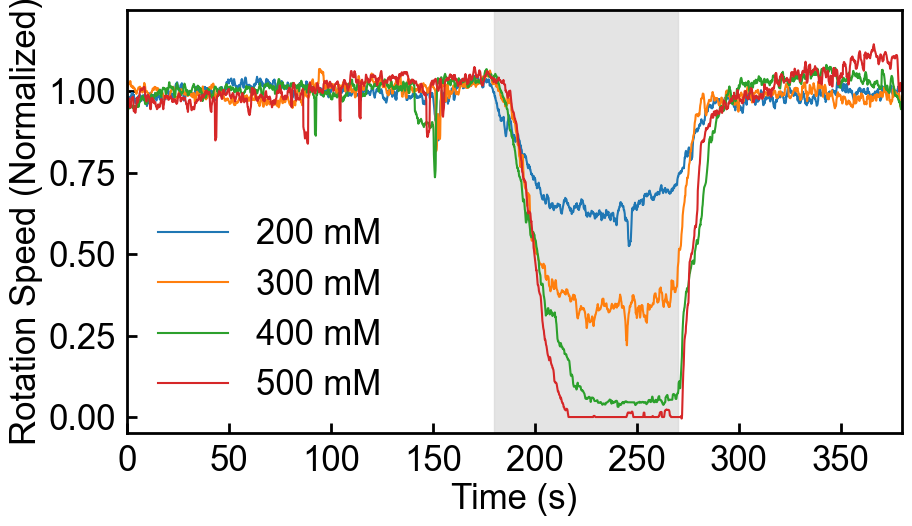

In [106]:
saving_choice=True

custom_legend_labels = ['200 mM', '300 mM', '400 mM', '500 mM']  # Manually set legend labels
# Plotting the sorted data
fig, ax = plt.subplots(figsize=(10, 5.5))

plt.rcParams.update({'font.size': 25})
plt.rcParams['font.family'] = 'Arial'

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

ax.tick_params(axis='x', direction='in', labelsize=25, width=2, length=7.5, pad=8)
ax.tick_params(axis='y', direction='in', labelsize=25, width=2, length=7.5, pad=8)

# Plot sorted data with integer concentrations in the legend
for time, data_norm_filt, conc in zip(sorted_times, sorted_data, sorted_concentrations):
    # Ensure time and data have the same length by trimming the longer one
    if len(time) > len(data_norm_filt):
        time = time[:len(data_norm_filt)]  # Trim time to match data length
    elif len(data_norm_filt) > len(time):
        data_norm_filt = data_norm_filt[:len(time)]  # Trim data to match time length

    # Now plot the data, both time and data have the same length
    ax.plot(time, data_norm_filt, label=f'{int(conc)}' + ' mM')  # Format concentration to int
    #plt.fill_between(time, lower[:len(time)], upper[:len(time)], alpha=0.5)  # Ensure lower and upper bounds match time length

# Finalizing the plot
#plt.xticks((100.0), fontsize=25)
ax.set_xlabel('Time (s)', fontsize=25)
ax.set_ylabel('Rotation Speed (Normalized)', fontsize=25)
ax.set_xlim(0, 380)
ax.set_ylim(-0.05, 1.25)  # Add space below zero

# Custom ticks
ax.set_xticks(np.arange(0, 381, 50))  # Set x-ticks every 50
ticks = np.arange(0, 1.26, 0.25)
ax.set_yticks(ticks[:-1])  # Remove the last tick (1.25)

ax.axvspan(180, 270, color="lightgray", alpha=0.6)

# Add the legend with sorted concentrations (formatted)
plt.legend(custom_legend_labels, loc='lower left', frameon=False, fontsize=25) # title="[Sucrose] mM", title_fontsize= 20, fontsize=15)
#plt.title('Clockwise Rotation in MB', loc='left', y=0.90, x=0.01, fontsize=20)

# Save the figure
if saving_choice:
    plt.savefig("/Users/luismeneses/Desktop/Clock-wise/overall_sucrose_trend.pdf", dpi=350)  # Save as PDF

# Show the plot
plt.show()

Available columns: Index(['concentration mm', 'read1', 'read2', 'avg_osmolarity',
       'change_in_osmolarity'],
      dtype='object')
Change in Osmolarity: [225.  379.5 560.5 756.5]
500mM
400mM
300mM
200mM


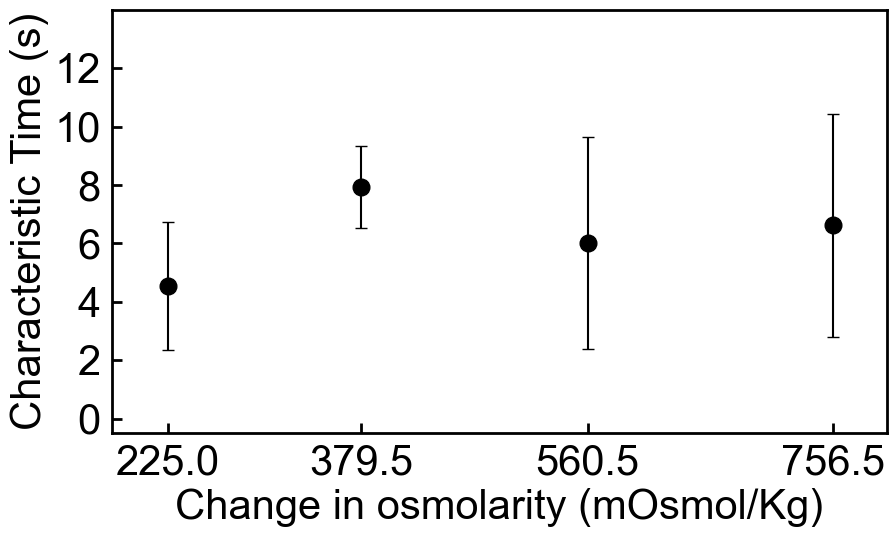

Average characteristic time: 6.283 s
Standard deviation of characteristic times: 1.218 s


In [107]:
# Set working directory
parentDir = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/clock-wise-results/plots'
os.chdir(parentDir)

fig, ax = plt.subplots(figsize=(10, 5.5))

plt.rcParams.update({'font.size': 30})
plt.rcParams['font.family'] = 'Arial'

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

ax.tick_params(axis='x', direction='in', labelsize=30, width=2, length=7.5, pad=8)
ax.tick_params(axis='y', direction='in', labelsize=30, width=2, length=7.5, pad=8)

file = "/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/clock-wise-results/plots/tau_values.csv"

# --- MODIFIED OSMOLARITY READING ---
# Path to the Excel file
excel_path = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Osmolarity-mesurments/sucrose-old.xlsx'
df_osmo = pd.read_excel(excel_path)

# Normalize column names: lowercase, no leading/trailing spaces
df_osmo.columns = df_osmo.columns.str.strip().str.lower()

# Check what columns exist
print("Available columns:", df_osmo.columns)

# Identify the read columns (allow space in name like 'read 1')
read_cols = [col for col in df_osmo.columns if 'read' in col]

if len(read_cols) < 2:
    raise ValueError("Could not find two 'Read' columns in the Excel file.")

# Average them
df_osmo['avg_osmolarity'] = df_osmo[read_cols[:2]].mean(axis=1)

# Calculate change relative to the first row
df_osmo['change_in_osmolarity'] = df_osmo['avg_osmolarity'] - df_osmo['avg_osmolarity'].iloc[0]

# Save back to the Excel file (overwrite)
df_osmo.to_excel(excel_path, index=False)

# Extract change values for plotting (excluding baseline row)
osmotic_shock_values = df_osmo['change_in_osmolarity'].iloc[1:].values
print("Change in Osmolarity:", osmotic_shock_values)

# --- MAIN PLOTTING SECTION ---
# --- MAIN PLOTTING SECTION ---
means = []
stds = []
concentrations = []
count = 0  # Initialize count

if file.endswith(".csv"):
    data = pd.read_csv(file)
    for column in data.keys():
        if column != "Unnamed: 0":
            print(column)
            standard_dev = np.std(data[column])
            mean = np.mean(data[column])

            # Use regex to safely extract number from column label
            match = re.search(r'\d+', column)
            if match:
                concentrations.append(int(match.group()))
            else:
                print(f"Skipping column due to invalid label: {column}")
                continue

            # ax.scatter([osmotic_shock_values[3 - count]] * len(data[column]), data[column],
            #            color='black', alpha=0.2)
            means.append(mean)
            stds.append(standard_dev)
            count += 1

    ax.errorbar(osmotic_shock_values, means, yerr=stds, marker="o", markeredgecolor='k',
                markersize=12, linestyle='None', color='black', ecolor='black', capsize=4)
    ax.set_xticks(osmotic_shock_values)

    # Finalizing the plot
    ax.set_xlabel('Change in osmolarity (mOsmol/Kg)', fontsize=30)
    ax.set_ylabel('Characteristic Time (s)', fontsize=30)
    ax.set_xlim(180, 800)
    #ax.set_yticks([-10.5, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6])
    ax.set_ylim(-0.5, 14)
    ax.set_yticks(np.arange(0, 14, 2))
    #plt.title('Clockwise Rotation in MB', loc='left', y=0.90, x=.55, fontsize=20)

    # Save and show plot
    plt.savefig('/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/clock-wise-results/plots/tau.pdf', dpi=350)
    plt.show()
    
    # --- SAVE AVERAGE TO TEXT FILE ---
       # --- SAVE AVERAGE AND STD OF MEANS TO TEXT FILE ---
    avg_tau = np.mean(means)
    std_tau = np.std(means)

    output_df = pd.DataFrame({
        "Change in Osmolarity (mOsmol/Kg)": osmotic_shock_values,
        "Mean Characteristic Time (s)": means,
        "Std Dev": stds
    })

    # Append a final row with overall average and std dev
    avg_row = pd.DataFrame({
        "Change in Osmolarity (mOsmol/Kg)": ["Average"],
        "Mean Characteristic Time (s)": [avg_tau],
        "Std Dev": [std_tau]
    })

    output_df = pd.concat([output_df, avg_row], ignore_index=True)
    output_df.to_csv('/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/clock-wise-results/plots/tau_summary.txt', sep='\t', index=False)

    print(f"Average characteristic time: {avg_tau:.3f} s")
    print(f"Standard deviation of characteristic times: {std_tau:.3f} s")


Change in Osmolarity: [225.  379.5 560.5 756.5]
Total Speed Decrease fit slope: 0.0020 | R²: 0.9999
Remaining Speed Decrease fit slope: 0.0015 | R²: 0.9996
Stats saved to: /Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/clock-wise-results/plots/A_linear_fit_stats.txt


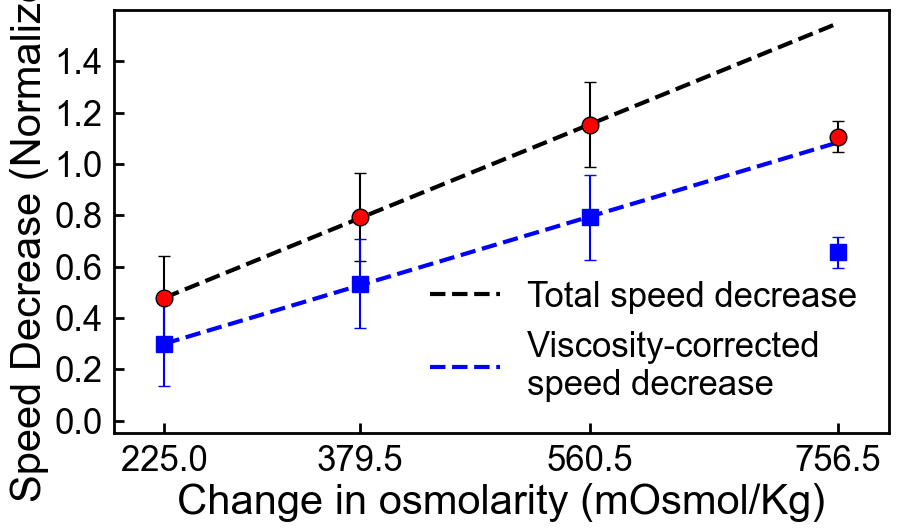

In [108]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from scipy.stats import linregress

# Set working directory
parentDir = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Bead-assays/clock-wise-results/plots'
os.chdir(parentDir)

file = os.path.join(parentDir, "A_values.csv")
excel_path = '/Users/luismeneses/ASU Dropbox/KE-TF Biodesign ME Wadhwa/Wadhwa Lab/Luis_M/Osmotic-shock-motor-response-project-2022-2025/Data/Osmolarity-mesurments/sucrose-old.xlsx'

# Plot setup
fig, ax = plt.subplots(figsize=(10, 5.5))
plt.rcParams.update({'font.size': 25})
plt.rcParams['font.family'] = 'Arial'

for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(2)

ax.tick_params(axis='x', direction='in', labelsize=25, width=2, length=7.5, pad=8)
ax.tick_params(axis='y', direction='in', labelsize=25, width=2, length=7.5, pad=8)

# Load osmolarity data
df_osmo = pd.read_excel(excel_path)
df_osmo.columns = df_osmo.columns.str.strip().str.lower()
read_cols = [col for col in df_osmo.columns if 'read' in col]

if len(read_cols) < 2:
    raise ValueError("Could not find two 'Read' columns in the Excel file.")

df_osmo['avg_osmolarity'] = df_osmo[read_cols[:2]].mean(axis=1)
df_osmo['change_in_osmolarity'] = df_osmo['avg_osmolarity'] - df_osmo['avg_osmolarity'].iloc[0]
df_osmo.to_excel(excel_path, index=False)

osmotic_shock_values = df_osmo['change_in_osmolarity'].iloc[1:].values
print("Change in Osmolarity:", osmotic_shock_values)

# --- Process A values ---
means = []
stds = []
concentrations = []
cleaned_columns = []

if file.endswith(".csv"):
    data = pd.read_csv(file)
    valid_columns = [col for col in data.columns if col != "Unnamed: 0"]

    for column in valid_columns:
        match = re.search(r'(\d+)', column)
        if match:
            concentration = int(match.group())
            cleaned_columns.append((concentration, column))
        else:
            print(f"⚠️ Skipping column due to invalid label: {column}")

    # Sort by concentration
    cleaned_columns.sort(key=lambda x: x[0])

    if len(cleaned_columns) != len(osmotic_shock_values):
        raise ValueError(f"❌ Mismatch between data columns ({len(cleaned_columns)}) and osmotic shock values ({len(osmotic_shock_values)}).")

    for i, (conc, col_name) in enumerate(cleaned_columns):
        col_data = data[col_name]
        means.append(np.mean(col_data))
        stds.append(np.std(col_data))
        concentrations.append(conc)

        # Optional scatter
        # ax.scatter([osmotic_shock_values[i]] * len(col_data), col_data, color='black', alpha=0.2)

    # --- Plot Total Speed Decrease ---
    ax.errorbar(
        osmotic_shock_values, means, yerr=stds,
        marker="o", markeredgecolor='k', markersize=12,
        linestyle='None', color='red', ecolor='black', capsize=4)
    #     label='Total Speed Decrease'
    # )

    ax.set_xticks(osmotic_shock_values)
    ax.set_xlabel('Change in osmolarity (mOsmol/Kg)')
    ax.set_ylabel('Speed Decrease (Normalized)')
    ax.set_ylim(-0.05, 1.6)
    ax.set_xlim(185, 796.5)
    ax.set_yticks(np.arange(0.0, 1.5, 0.2))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}'))
    
   
    # === Linear Fit for Total Speed Decrease ===
    x_data = np.array(osmotic_shock_values[:3])  # only first 3 osmolarity values
    y_data = np.array(means[:3])                 # only first 3 A values

    # Perform linear regression on first 3 points
    slope, intercept, r_value, p_value, std_err = linregress(x_data, y_data)

    # Plot the trend line up to the 4th osmolarity value
    x_fit = np.linspace(x_data[0], osmotic_shock_values[3], 500)
    y_fit = slope * x_fit + intercept
    ax.plot(x_fit, y_fit, linestyle="--", color="black", linewidth=3, label="Total speed decrease")

    # === Viscosity Correction (Sucrose-matched values) ===
    viscosity_dict = {
        200: 0.18,
        300: 0.26,
        400: 0.36,
        500: 0.45
    }

    viscosities = [viscosity_dict.get(c, 0) for c in concentrations]
    diff_values = np.array(means) - np.array(viscosities)

    ax.errorbar(
        osmotic_shock_values, diff_values, yerr=stds,
        marker="s", markeredgecolor='blue', markersize=12,
        linestyle='None', color='blue', ecolor='blue', capsize=4)
    #     label='Remaining Speed Decrease'
    # )
    
    # === Linear Fit for Remaining Speed Decrease ===
    diff_data = np.array(diff_values[:3])  # use only first 3 viscosity-corrected means

    # Linear regression using only first 3 osmolarity points
    slope_diff, intercept_diff, r_value_diff, p_value_diff, std_err_diff = linregress(x_data, diff_data)

    # Plot trend line up to the 4th osmolarity value
    x_fit_diff = np.linspace(x_data[0], osmotic_shock_values[3], 500)
    y_fit_diff = slope_diff * x_fit_diff + intercept_diff
    ax.plot(x_fit_diff, y_fit_diff, linestyle="--", color="blue", linewidth=3, label="Viscosity-corrected \nspeed decrease")

    # Add legend
    ax.legend(loc='lower right', frameon = False)

    # Print fit stats
    print(f"Total Speed Decrease fit slope: {slope:.4f} | R²: {r_value**2:.4f}")
    print(f"Remaining Speed Decrease fit slope: {slope_diff:.4f} | R²: {r_value_diff**2:.4f}")

    # Save stats
    stats_output_path = os.path.join(parentDir, "A_linear_fit_stats.txt")
    with open(stats_output_path, 'w') as f:
        f.write("Linear Fit Statistics - Total Speed Decrease\n")
        f.write("===========================================\n")
        f.write(f"Slope: {slope:.6f}\nIntercept: {intercept:.6f}\nR-squared: {r_value**2:.6f}\n")
        f.write(f"P-value: {p_value:.6e}\nStandard Error: {std_err:.6f}\n\n")

        f.write("Linear Fit Statistics - Remaining Speed Decrease\n")
        f.write("===============================================\n")
        f.write(f"Slope: {slope_diff:.6f}\nIntercept: {intercept_diff:.6f}\nR-squared: {r_value_diff**2:.6f}\n")
        f.write(f"P-value: {p_value_diff:.6e}\nStandard Error: {std_err_diff:.6f}\n")

    print(f"Stats saved to: {stats_output_path}")

    # Save plot
    plt.savefig(os.path.join(parentDir, "A_linear_fit.pdf"), dpi=350)
    plt.show()